№1.Построить график функции y1−α+β − yβ для β ∈ (0, α), где yt – квантиль распределения 

(a) N(0, 1),

(b) Gamma(n, 1), n = 1, 2, 5, 10, 100,

(c) R[0, 1],

(d) Beta(a, b), a = b = 5, a = 10, b = 2, a = 20, b = 1.

Рассмотреть одно любое значение α, например, α = 0.001, 0.05, 0.1. Сделать вывод о выборе оптимального β для построения доверительного интервала на основе статистики с нашим распределением.

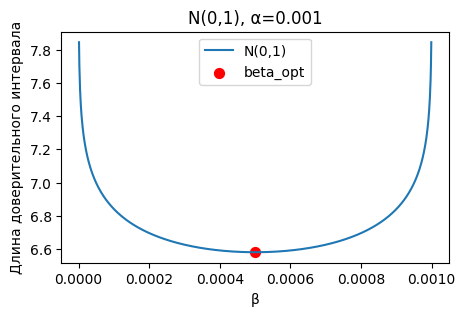

N(0,1): β_opt=0.0005, min длина=6.581053462983758


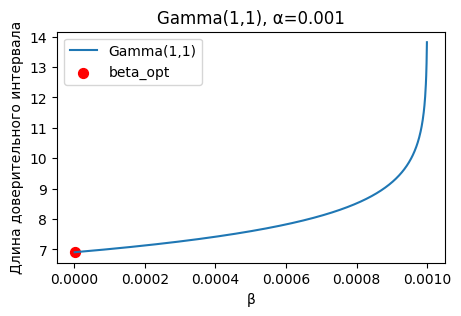

Gamma(1,1): β_opt=1e-06, min длина=6.908754779315249


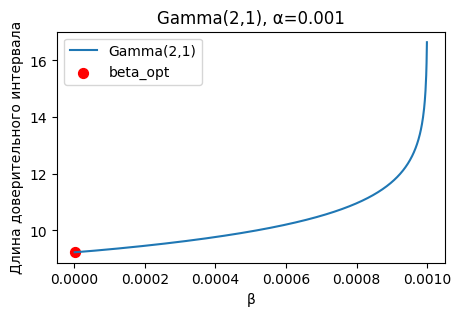

Gamma(2,1): β_opt=1e-06, min длина=9.233107446114246


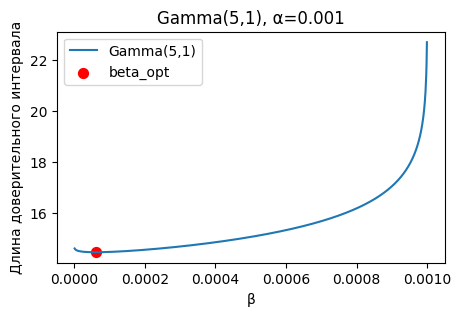

Gamma(5,1): β_opt=6.0251724419919264e-05, min длина=14.478319082165218


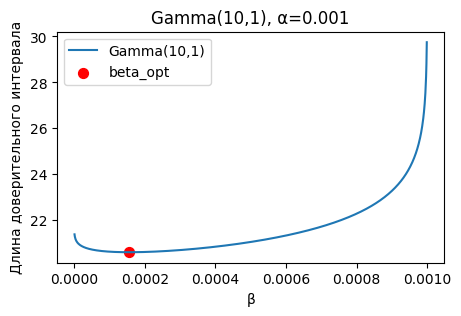

Gamma(10,1): β_opt=0.00015597601390493807, min длина=20.603661003321562


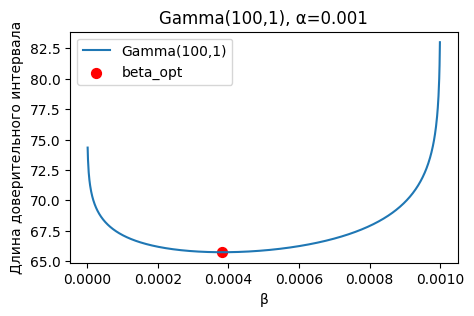

Gamma(100,1): β_opt=0.00038243485538972305, min длина=65.73524150904579


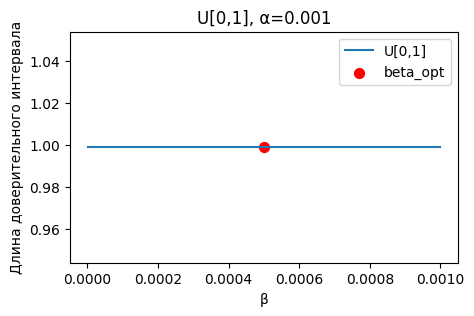

U[0,1]: β_opt=0.0005, min длина=0.999


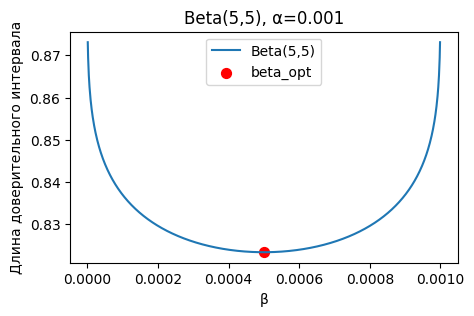

Beta(5,5): β_opt=0.0005, min длина=0.8233048346749122


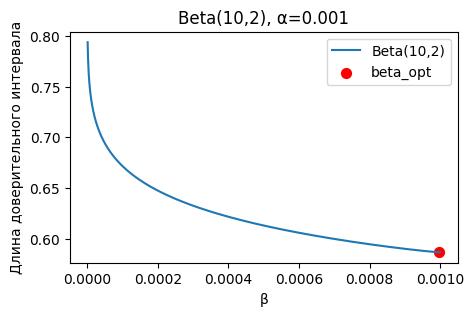

Beta(10,2): β_opt=0.0009963922628936296, min длина=0.5865439979769408


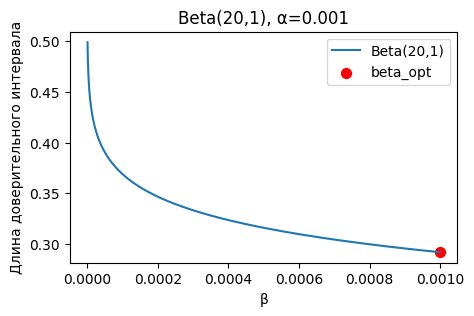

Beta(20,1): β_opt=0.000999, min длина=0.29208957972970684


In [1]:
import numpy as np
import matplotlib.pyplot as plt
#ppf = Percent Point Function = Обратная функция распределения = квантиль
def conf_int_len(dist, alpha, beta):
    if beta <= 0 or beta >= alpha:
        return np.inf   #почему? потому что F^{-1}(0)=-inf  и F^{-1}(1 - alpha + alpha) = F^{-1}(1)= +inf
    y_beta = dist.ppf(beta)
    y_1_alpha_beta = dist.ppf(1 - alpha + beta)
    return y_1_alpha_beta - y_beta

from scipy.optimize import minimize
def find_optimal_beta(dist, alpha):
    beta_init = alpha / 2
    bounds = [(1e-6, alpha - 1e-6)]
    result = minimize(lambda beta: conf_int_len(dist, alpha, beta), beta_init, bounds=bounds)
    return result.x[0]

def plot_conf_int_len(dist, dist_name, alpha=0.001):
    beta_values = np.linspace(1e-6, alpha - 1e-6, 1000)
    lengths = []
    for beta in beta_values:
        length = conf_int_len(dist, alpha, beta)
        lengths.append(length)
    
    beta_opt = find_optimal_beta(dist, alpha)
    min_len = conf_int_len(dist, alpha, beta_opt)
    
    plt.figure(figsize=(5, 3))
    plt.plot(beta_values, lengths, label=dist_name)
    plt.scatter(beta_opt, min_len, color='red', s=50, label = 'beta_opt')
    
    plt.xlabel('β')
    plt.ylabel('Длина доверительного интервала')
    plt.title(f'{dist_name}, α={alpha}')
    plt.legend()
    plt.show()
    
    print(f"{dist_name}: β_opt={beta_opt}, min длина={min_len}")
    
    return beta_opt, min_len

from scipy.stats import norm, gamma, uniform, beta

alpha = 0.001


norm_dist = norm(0, 1)
beta_opt_norm, min_len_norm = plot_conf_int_len(norm_dist, "N(0,1)", alpha)

for n in [1, 2, 5, 10, 100]:
    gamma_dist = gamma(n, scale=1)
    beta_gamma, len_gamma = plot_conf_int_len(gamma_dist, f"Gamma({n},1)", alpha)

uniform_dist = uniform(0, 1)
beta_opt_unif, min_len_unif = plot_conf_int_len(uniform_dist, "U[0,1]", alpha)

for a, b in [(5, 5), (10, 2), (20, 1)]:
    beta_dist = beta(a, b)
    beta_beta, len_beta = plot_conf_int_len(beta_dist, f"Beta({a},{b})", alpha)

№2. X1, ..., Xn ∼ R[0, θ].

(a) Построить асимптотический доверительный интервал, используя X. Найти эмпирически доверительную вероятность этого интервала (построить 1000 выборок, подсчитать долю тех, для которых интервал накрыл истинное значение параметра, для n = 20, 50, 100)

(b) Построить точный доверительный интервал, используя достаточную статистику. Сравнить средние длины точного и асимптотического интервалов при n = 20, 50, 100.

In [ ]:
from scipy import stats
def find_asymp_interval(theta_true, N_simulations):
    for n in n_values: 
        length = []
        good = 0  
        for i in range(N_simulations):
            sample = np.random.uniform(0, theta_true, n)
            theta_lower = 2*np.mean(sample)/(z2/np.sqrt(3*n) + 1)
            theta_upper = 2*np.mean(sample)/(z1/np.sqrt(3*n) + 1)
            length.append(theta_upper - theta_lower)
            if theta_lower <= theta_true <= theta_upper:
                good += 1
        emp_probability = good/N_simulations
        asymp_length = np.mean(length)
        print(f"Размер выборки {n}, эмпирическая вероятность {emp_probability}, средняя длина {asymp_length}")
    return emp_probability, asymp_length
 
def find_exact_interval(theta_true, N_simulations, alpha):
    for n in n_values:
        length = []
        for i in range(N_simulations):
            sample = np.random.uniform(0, theta_true, n)
            X_max = np.max(sample) #достаточная статистика
            theta_lower = X_max
            theta_upper = X_max / ((alpha)**(1/n))
            length.append(theta_upper - theta_lower)
        exact_length = np.mean(length)
        print(f"Размер выборки {n}, средняя длина {exact_length}")
    return exact_length

theta_true = 1  
n_values = [20, 50, 100]
N_simulations = 1000
alpha = 0.05  
z1 = stats.norm.ppf(alpha/2)
z2 = stats.norm.ppf(1 - alpha/2)

find_asymp_interval(theta_true, N_simulations)        
find_exact_interval(theta_true, N_simulations, alpha)


Размер выборки 20, эмпирическая вероятность 0.953, средняя длина 0.5417113264313109
Размер выборки 50, эмпирическая вероятность 0.955, средняя длина 0.32858625089224164
Размер выборки 100, эмпирическая вероятность 0.944, средняя длина 0.22913266134973168
Размер выборки 20, средняя длина 0.15380352576013007
Размер выборки 50, средняя длина 0.06059881006836008
Размер выборки 100, средняя длина 0.030106853828635222


np.float64(0.030106853828635222)

3. X1, ..., Xn ∼ Bern(θ). а) Построить асимптотический доверительный интервал двумя способами
с помощью X, сравнить средние длины полученных интервалов (генерировать 1000 выборок, по
каждой строить оба интервала, посчитать и показать средние длины) для θ = 0.1, 0.4, 0.5, 0.9 и
n = 20, 50, 100. б) Найти точный уровень доверия в зависимости от n и построить график при n
от 20 до 100.
![dg](asymp_conf_int.jpg)

Параметр θ = 0.1, размер выборки 20
 Способ 1 : средняя длина 0.23598008372018076, уровень доверия 0.888
 Способ 2 : средняя длина 0.2284980695505668, уровень доверия 0.882

Параметр θ = 0.1, размер выборки 22
 Способ 1 : средняя длина 0.22445464661866094, уровень доверия 0.9
 Способ 2 : средняя длина 0.21797936859713238, уровень доверия 0.889

Параметр θ = 0.1, размер выборки 24
 Способ 1 : средняя длина 0.2198952030930614, уровень доверия 0.913
 Способ 2 : средняя длина 0.21407587142983356, уровень доверия 0.895

Параметр θ = 0.1, размер выборки 26
 Способ 1 : средняя длина 0.2116496517713104, уровень доверия 0.934
 Способ 2 : средняя длина 0.20647620168439304, уровень доверия 0.929

Параметр θ = 0.1, размер выборки 28
 Способ 1 : средняя длина 0.2089534204799961, уровень доверия 0.944
 Способ 2 : средняя длина 0.20420819614072797, уровень доверия 0.924

Параметр θ = 0.1, размер выборки 30
 Способ 1 : средняя длина 0.2027231220331907, уровень доверия 0.812
 Способ 2 : средняя длина 0

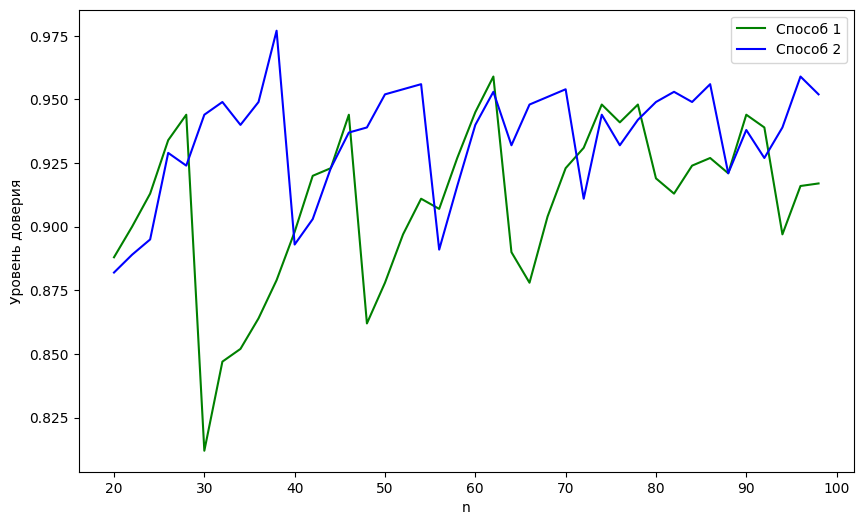

Параметр θ = 0.4, размер выборки 20
 Способ 1 : средняя длина 0.417375134272172, уровень доверия 0.928
 Способ 2 : средняя длина 0.404141785849549, уровень доверия 0.928

Параметр θ = 0.4, размер выборки 22
 Способ 1 : средняя длина 0.39920797206682795, уровень доверия 0.949
 Способ 2 : средняя длина 0.3876912463207348, уровень доверия 0.949

Параметр θ = 0.4, размер выборки 24
 Способ 1 : средняя длина 0.3832577957631828, уровень доверия 0.94
 Способ 2 : средняя длина 0.3731152178683857, уровень доверия 0.94

Параметр θ = 0.4, размер выборки 26
 Способ 1 : средняя длина 0.3693907486614418, уровень доверия 0.931
 Способ 2 : средняя длина 0.3603615601663249, уровень доверия 0.967

Параметр θ = 0.4, размер выборки 28
 Способ 1 : средняя длина 0.3557530925859032, уровень доверия 0.949
 Способ 2 : средняя длина 0.3476741234556987, уровень доверия 0.949

Параметр θ = 0.4, размер выборки 30
 Способ 1 : средняя длина 0.34570959133592793, уровень доверия 0.949
 Способ 2 : средняя длина 0.33837

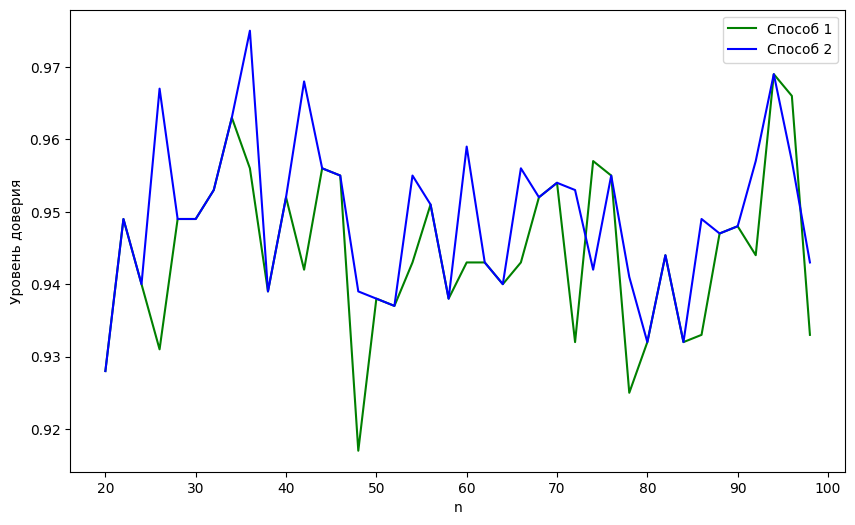

Параметр θ = 0.5, размер выборки 20
 Способ 1 : средняя длина 0.4268913432975072, уровень доверия 0.96
 Способ 2 : средняя длина 0.41335627275644904, уровень доверия 0.96

Параметр θ = 0.5, размер выборки 22
 Способ 1 : средняя длина 0.4083076935133323, уровень доверия 0.947
 Способ 2 : средняя длина 0.39652845047400326, уровень доверия 0.947

Параметр θ = 0.5, размер выборки 24
 Способ 1 : средняя длина 0.392109413058048, уровень доверия 0.944
 Способ 2 : средняя длина 0.3817325849564694, уровень доверия 0.944

Параметр θ = 0.5, размер выборки 26
 Способ 1 : средняя длина 0.37720151966609355, уровень доверия 0.927
 Способ 2 : средняя длина 0.36798140889165937, уровень доверия 0.927

Параметр θ = 0.5, размер выборки 28
 Способ 1 : средняя длина 0.36375152958297, уровень доверия 0.92
 Способ 2 : средняя длина 0.3554909200765161, уровень доверия 0.968

Параметр θ = 0.5, размер выборки 30
 Способ 1 : средняя длина 0.3522142115452958, уровень доверия 0.971
 Способ 2 : средняя длина 0.34474

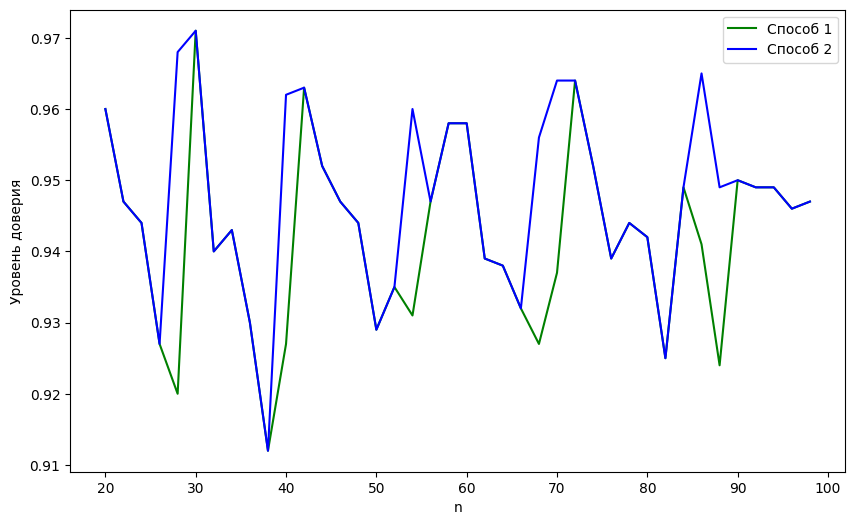

Параметр θ = 0.9, размер выборки 20
 Способ 1 : средняя длина 0.23724343241171386, уровень доверия 0.883
 Способ 2 : средняя длина 0.2297213623498306, уровень доверия 0.873

Параметр θ = 0.9, размер выборки 22
 Способ 1 : средняя длина 0.22785116691021662, уровень доверия 0.906
 Способ 2 : средняя длина 0.22127790288784138, уровень доверия 0.895

Параметр θ = 0.9, размер выборки 24
 Способ 1 : средняя длина 0.2177906406081553, уровень доверия 0.906
 Способ 2 : средняя длина 0.21202700432587887, уровень доверия 0.888

Параметр θ = 0.9, размер выборки 26
 Способ 1 : средняя длина 0.2110559545095105, уровень доверия 0.932
 Способ 2 : средняя длина 0.20589701643867706, уровень доверия 0.925

Параметр θ = 0.9, размер выборки 28
 Способ 1 : средняя длина 0.2039259926565522, уровень доверия 0.934
 Способ 2 : средняя длина 0.19929493860852368, уровень доверия 0.924

Параметр θ = 0.9, размер выборки 30
 Способ 1 : средняя длина 0.20619036578103217, уровень доверия 0.828
 Способ 2 : средняя длин

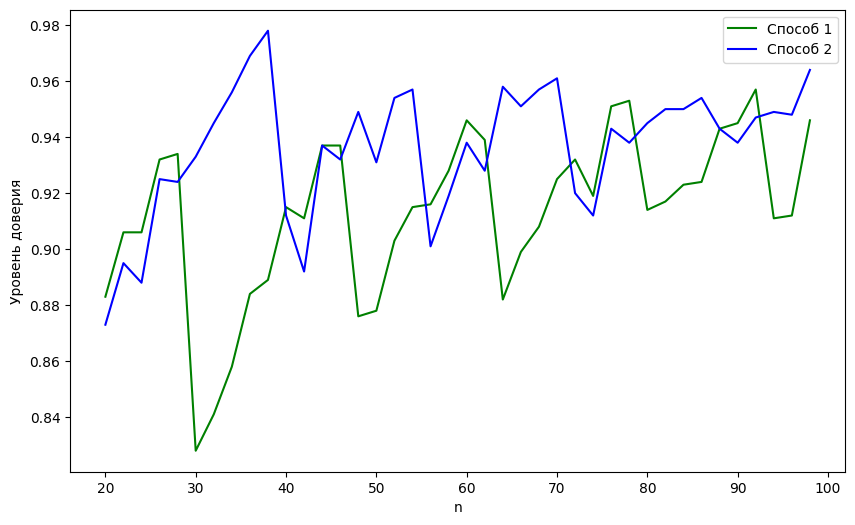

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
def bild_asymp_int (n_values, theta_values, N_simulations):
    for theta in theta_values:
        level_of_trust_1 = []
        level_of_trust_2 = []
        for n in n_values: 
            length_1 = []
            length_2 = []
            good_1 = 0
            good_2 = 0
            for i in range(N_simulations):
                sample = np.random.binomial(1, theta, n)
                #Способ 1. Подстановка оценки σ̂ = σ(θ̂), θ̂  = np.mean(sample)
                mean = np.mean(sample) #асимптотически нормальная оценка
                theta_lower_1 = mean - z2 * np.sqrt(mean*(1 - mean) / n)
                theta_upper_1 = mean - z1 * np.sqrt(mean*(1 - mean) / n)
                length_1.append(theta_upper_1 - theta_lower_1)
                if theta_lower_1 <= theta <= theta_upper_1:
                    good_1 += 1
                #Способ 2. Стабилизация асимптотической дисперсии g(θ) = arcsin(2θ - 1) => g^-1 = (sin(θ)+1)/2
                left = np.arcsin(mean*2 - 1) - z2 / np.sqrt(n)
                right = np.arcsin(mean*2 - 1) - z1 / np.sqrt(n)
                theta_lower_2 = (np.sin(left) + 1) / 2
                theta_upper_2 = (np.sin(right) + 1) / 2
                length_2.append(theta_upper_2 - theta_lower_2)
                if theta_lower_2 <= theta <= theta_upper_2:
                    good_2 += 1
            mean_len_1 = np.mean(length_1)
            mean_len_2 = np.mean(length_2)
            lev_of_trust_1 = good_1 / N_simulations
            lev_of_trust_2 = good_2 / N_simulations
            level_of_trust_1.append(lev_of_trust_1)
            level_of_trust_2.append(lev_of_trust_2)
            print(f"Параметр θ = {theta}, размер выборки {n}\n Способ 1 : средняя длина {mean_len_1}, уровень доверия {lev_of_trust_1}\n Способ 2 : средняя длина {mean_len_2}, уровень доверия {lev_of_trust_2}\n")
        #Визуализируем
        plt.figure(figsize=(10, 6))
        plt.plot(n_values, level_of_trust_1, color='green', label='Способ 1')
        plt.plot(n_values, level_of_trust_2, color='blue', label='Способ 2')

        plt.xlabel('n')
        plt.ylabel('Уровень доверия')
        plt.legend()
        plt.show()

n_values = np.arange(20, 100, 2)
theta_values = [0.1, 0.4, 0.5, 0.9]
N_simulations = 1000
alpha = 0.05
z1 = stats.norm.ppf(alpha/2)
z2 = stats.norm.ppf(1 - alpha/2) #-z1

bild_asymp_int (n_values, theta_values, N_simulations)                